In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn pyarrow jupyterlab

  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi_bindings-25.1.0-cp39-abi3-win_amd

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="pastel")
BASE_DIR = 'C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer'
DATA_DIR = f'{BASE_DIR}/'
PROCESSED_DIR = f'{BASE_DIR}/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Starting Ingestion Pipeline...")

Starting Ingestion Pipeline...


In [4]:
def load_and_clean_network_data(filepath):
    print(f"Loading {filepath}...")
    df = pd.read_csv(filepath, skipinitialspace=True)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    initial_shape = df.shape
    df.dropna(inplace=True)
    print(f"Dropped {initial_shape[0] - df.shape[0]} rows containing NaNs/Infinities.")
    
    return df

cicids_df = load_and_clean_network_data(f'{DATA_DIR}Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

Loading C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Dropped 34 rows containing NaNs/Infinities.



--- Dataset Info ---
<class 'pandas.DataFrame'>
Index: 225711 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   destination_port             225711 non-null  int64  
 1   flow_duration                225711 non-null  int64  
 2   total_fwd_packets            225711 non-null  int64  
 3   total_backward_packets       225711 non-null  int64  
 4   total_length_of_fwd_packets  225711 non-null  int64  
 5   total_length_of_bwd_packets  225711 non-null  int64  
 6   fwd_packet_length_max        225711 non-null  int64  
 7   fwd_packet_length_min        225711 non-null  int64  
 8   fwd_packet_length_mean       225711 non-null  float64
 9   fwd_packet_length_std        225711 non-null  float64
 10  bwd_packet_length_max        225711 non-null  int64  
 11  bwd_packet_length_min        225711 non-null  int64  
 12  bwd_packet_length_mean       225711 non-null  float6

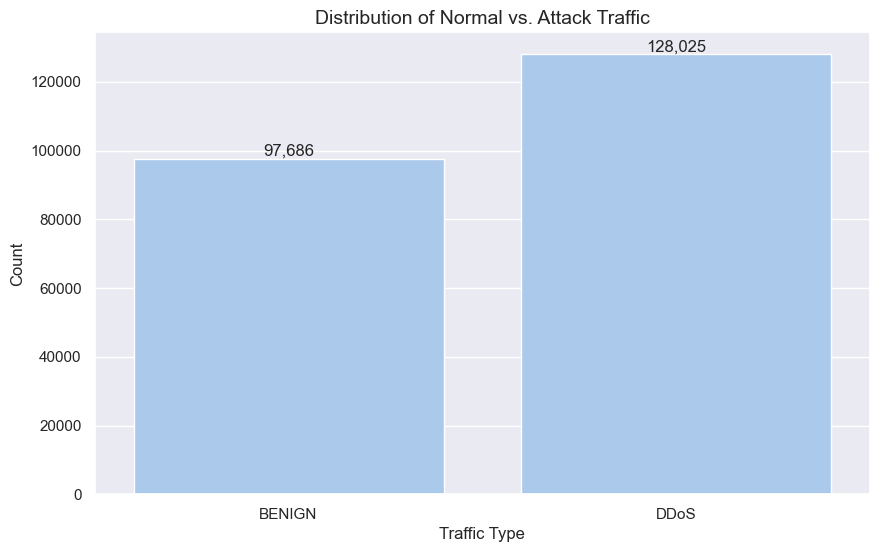

In [5]:
print("\n--- Dataset Info ---")
print(cicids_df.info())

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=cicids_df, x='label')
plt.title('Distribution of Normal vs. Attack Traffic', fontsize=14)
plt.xlabel('Traffic Type')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

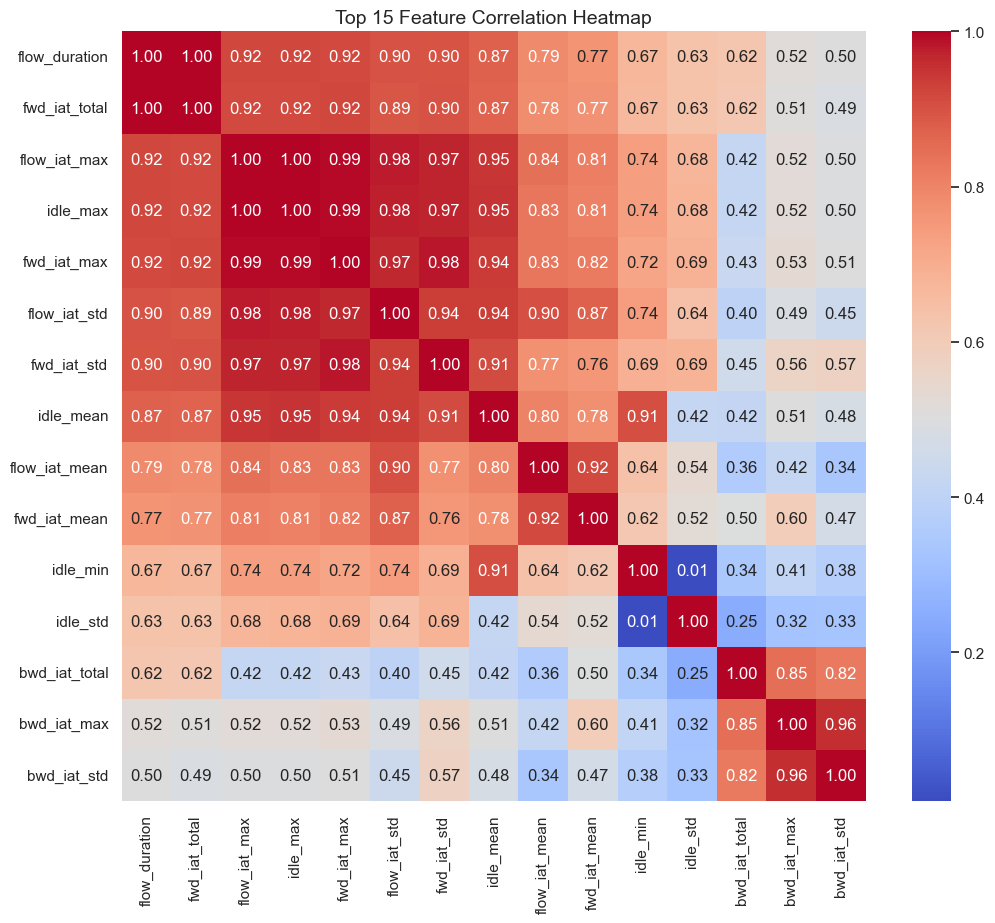

In [6]:
num_cols = cicids_df.select_dtypes(include=[np.number]).columns
corr_sample = cicids_df[num_cols].sample(n=min(50000, len(cicids_df)), random_state=42)
corr_matrix = corr_sample.corr()
plt.figure(figsize=(12, 10))
top_corr_features = corr_matrix.nlargest(15, 'flow_duration')['flow_duration'].index
sns.heatmap(corr_sample[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Feature Correlation Heatmap', fontsize=14)
plt.show()

In [7]:
output_path = f'{PROCESSED_DIR}cicids_cleaned.parquet'
cicids_df.to_parquet(output_path, engine='pyarrow')
print(f"\nSanitized data saved successfully to {output_path}")
print("Ready for Notebook 2: Feature Engineering.")


Sanitized data saved successfully to C:/Users/SATWIK GHOSH/OneDrive/Desktop/AI-Powered Cyberthreat Analyzer/processed/cicids_cleaned.parquet
Ready for Notebook 2: Feature Engineering.
